# Сравнение методов поиска похожих фильмов


In [1]:
!pip install -U sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 739.6/739.6 kB 9.8 MB/s eta 0:00:00
  Attempting uninstall: sentence-transformers
    Found existing installation: sentence-transformers 5.7.0
    Uninstalling sentence-transformers-5.7.0:
      Successfully uninstalled sentence-transformers-5.7.0


In [2]:
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer


## 1. Постановка задачи

Цель проекта - разработать и сравнить несколько методов поиска фильмов, похожих по содержанию.

Будут рассмотрены три подхода:

1. **Baseline по жанрам** - фильм представляется набором жанров.
2. **TF-IDF по описаниям** - фильм представляется вектором важных слов из `overview`.
3. **Sentence Transformer** - описание фильма преобразуется в семантический эмбеддинг предобученной нейросетевой моделью.

Для каждого фильма каждый метод формирует **Top-10** наиболее похожих фильмов.

Для оценки качества используется **MovieLens Tag Genome**. Сходство между векторами пользовательских тегов исходного и рекомендованных фильмов используется как независимая proxy-метрика.

Основные данные берутся из **The Movies Dataset**, а Tag Genome используется только для оценки качества.


## 2. Загрузка данных

Сначала загрузим два источника данных: **The Movies Dataset** с описаниями и жанрами фильмов и **MovieLens Tag Genome** с профилями пользовательских тегов.


**The Movies Dataset:** https://www.kaggle.com/datasets/rounakbanik/the-movies-dataset


In [3]:
!gdown 18WHFWz_XVh2CsWoT8tp0OfOGO0LW1gtl

Downloading...
From: https://drive.google.com/uc?id=18WHFWz_XVh2CsWoT8tp0OfOGO0LW1gtl
To: /content/movies_metadata.csv
100% 34.4M/34.4M [00:00<00:00, 37.6MB/s]


In [4]:
movies = pd.read_csv("movies_metadata.csv")

/tmp/ipykernel_2200/2321092756.py:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  movies = pd.read_csv("movies_metadata.csv")


Проверим размер, типы данных и первые строки основного датасета.


In [5]:
movies.shape

(45466, 24)

In [6]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  45466 non-null  object 
 1   belongs_to_collection  4494 non-null   object 
 2   budget                 45466 non-null  object 
 3   genres                 45466 non-null  object 
 4   homepage               7782 non-null   object 
 5   id                     45466 non-null  object 
 6   imdb_id                45449 non-null  object 
 7   original_language      45455 non-null  object 
 8   original_title         45466 non-null  object 
 9   overview               44512 non-null  object 
 10  popularity             45461 non-null  object 
 11  poster_path            45080 non-null  object 
 12  production_companies   45463 non-null  object 
 13  production_countries   45463 non-null  object 
 14  release_date           45379 non-null  object 
 15  re

In [7]:
movies.head()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


Загрузим три файла MovieLens Tag Genome: справочник фильмов для последующего сопоставления датасетов, справочник тегов и значения relevance для каждой пары фильм–тег.

https://grouplens.org/datasets/movielens/tag-genome/


In [8]:
!gdown 1YPcBo3Ahlj4qIvYNdj8UVRo9zoEP2CSc
!gdown 122KYrNUFVtkgytQGRMDthmlE35NZ4int
!gdown 1iBVG4KUr5Rm36mrtk4PEe0P8LZJEoSFO

Downloading...
From: https://drive.google.com/uc?id=1YPcBo3Ahlj4qIvYNdj8UVRo9zoEP2CSc
To: /content/movies.dat
100% 353k/353k [00:00<00:00, 62.2MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=122KYrNUFVtkgytQGRMDthmlE35NZ4int
From (redirected): https://drive.google.com/uc?id=122KYrNUFVtkgytQGRMDthmlE35NZ4int&confirm=t&uuid=551e36ed-9779-40db-b192-564cca931906
To: /content/tag_relevance.dat
100% 167M/167M [00:04<00:00, 34.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=1iBVG4KUr5Rm36mrtk4PEe0P8LZJEoSFO
To: /content/tags.dat
100% 20.6k/20.6k [00:00<00:00, 35.5MB/s]


In [9]:
tag_movies = pd.read_csv("movies.dat", sep="\t", names=["movie_id", "title", "popularity"])

In [10]:
tag_movies.shape

(9734, 3)

In [11]:
tag_movies.head(10)

,movie_id,title,popularity
0,1,Toy Story (1995),53059
1,2,Jumanji (1995),22466
2,3,Grumpier Old Men (1995),15111
3,4,Waiting to Exhale (1995),2898
4,5,Father of the Bride Part II (1995),14323
5,6,Heat (1995),25275
6,7,Sabrina (1995),14628
7,8,Tom and Huck (1995),1443
8,9,Sudden Death (1995),4255
9,10,GoldenEye (1995),30429


In [12]:
tags = pd.read_csv("tags.dat", sep="\t", names=["tag_id", "tag", "popularity"])

In [13]:
tags.shape

(1128, 3)

In [14]:
tags.head(10)

,tag_id,tag,popularity
0,0,007,61
1,1,007 (series),24
2,2,18th century,37
3,3,1920s,42
4,4,1930s,55
5,5,1950s,49
6,6,1960s,57
7,7,1970s,71
8,8,1980s,109
9,9,19th century,68


In [15]:
tag_relevance = pd.read_csv("tag_relevance.dat", sep="\t", names=["movie_id", "tag_id", "relevance"])

In [16]:
tag_relevance.shape

(10979952, 3)

In [17]:
tag_relevance.head(10)

,movie_id,tag_id,relevance
0,1,0,0.032
1,1,1,0.035
2,1,2,0.070
3,1,3,0.114
4,1,4,0.105
5,1,5,0.186
6,1,6,0.040
7,1,7,0.208
8,1,8,0.261
9,1,9,0.032


## 3. Исследование данных

Проведём небольшой EDA только по признакам, которые относятся к задаче: пропускам, жанрам и текстовым описаниям. Остальные поля подробно исследовать не будем, так как они не используются в моделях.


Сначала посмотрим на количество и долю пропусков.


In [18]:
eda_columns = ["id", "title", "release_date", "genres", "overview"]

missing = pd.DataFrame({"missing_count": movies[eda_columns].isna().sum(), "missing_percent": movies[eda_columns].isna().mean() * 100})

missing

,missing_count,missing_percent
id,0,0.000000
title,6,0.013197
release_date,87,0.191352
genres,0,0.000000
overview,954,2.098271


Среди исследуемых признаков наибольшее количество пропусков содержится в overview: около 2,1% записей. В release_date и title пропусков немного, а в id и genres значения NaN отсутствуют. Для genres дополнительно проверим наличие пустых списков, которые не учитываются методом isna().

Жанры хранятся как строковое представление списка словарей. Проверим примеры и наличие пустых списков, затем извлечём только названия жанров.


In [19]:
movies[["title", "genres"]].head(10)

,title,genres
0,Toy Story,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '..."
1,Jumanji,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '..."
2,Grumpier Old Men,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ..."
3,Waiting to Exhale,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam..."
4,Father of the Bride Part II,"[{'id': 35, 'name': 'Comedy'}]"
5,Heat,"[{'id': 28, 'name': 'Action'}, {'id': 80, 'nam..."
6,Sabrina,"[{'id': 35, 'name': 'Comedy'}, {'id': 10749, '..."
7,Tom and Huck,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam..."
8,Sudden Death,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam..."
9,GoldenEye,"[{'id': 12, 'name': 'Adventure'}, {'id': 28, '..."


In [20]:
(movies["genres"] == "[]").sum()

np.int64(2442)

Хотя в `genres` нет значений NaN, для 2442 фильмов жанры представлены пустым списком []. Такие записи не могут использоваться в модели, основанной на жанрах, поэтому их необходимо учесть при дальнейшей подготовке данных.

Преобразуем строковое представление жанров в список и сохраним только их названия в новом столбце genres_list.

In [21]:
movies["genres_list"] = movies["genres"].apply(lambda x: [genre["name"] for genre in ast.literal_eval(x)])

In [22]:
genre_counts = movies["genres_list"].explode().value_counts()

genre_counts

,count
genres_list,
Drama,20265
Comedy,13182
Thriller,7624
Romance,6735
Action,6596
Horror,4673
Crime,4307
Documentary,3932
Adventure,3496


При просмотре жанров обнаружились несколько аномальных значений, которые на самом деле являются названиями компаний. Выделим допустимый набор жанров, найдём повреждённые строки и удалим их.


Сформируем список допустимых жанров valid_genres.

In [23]:
valid_genres = [
    "Drama", "Comedy", "Thriller", "Romance", "Action",
    "Horror", "Crime", "Documentary", "Adventure",
    "Science Fiction", "Family", "Mystery", "Fantasy",
    "Animation", "Foreign", "Music", "History", "War",
    "Western", "TV Movie"
]

Затем найдём фильмы, в `genres_list` которых присутствует хотя бы одно значение, не входящее в этот список. Такие строки сохраним в invalid_genres для проверки.

In [24]:
invalid_genres = movies[
    movies["genres_list"].apply(
        lambda genres: any(genre not in valid_genres for genre in genres)
    )
]

invalid_genres[["title", "id", "genres_list"]]

,title,id,genres_list
19730,NaN,1997-08-20,"[Carousel Productions, Vision View Entertainme..."
29503,NaN,2012-09-29,"[Aniplex, GoHands, BROSTA TV, Mardock Scramble..."
35587,NaN,2014-01-01,"[Odyssey Media, Pulser Productions, Rogue Stat..."


Посмотрим распределение фильмов по жанрам и количество жанров на один фильм.


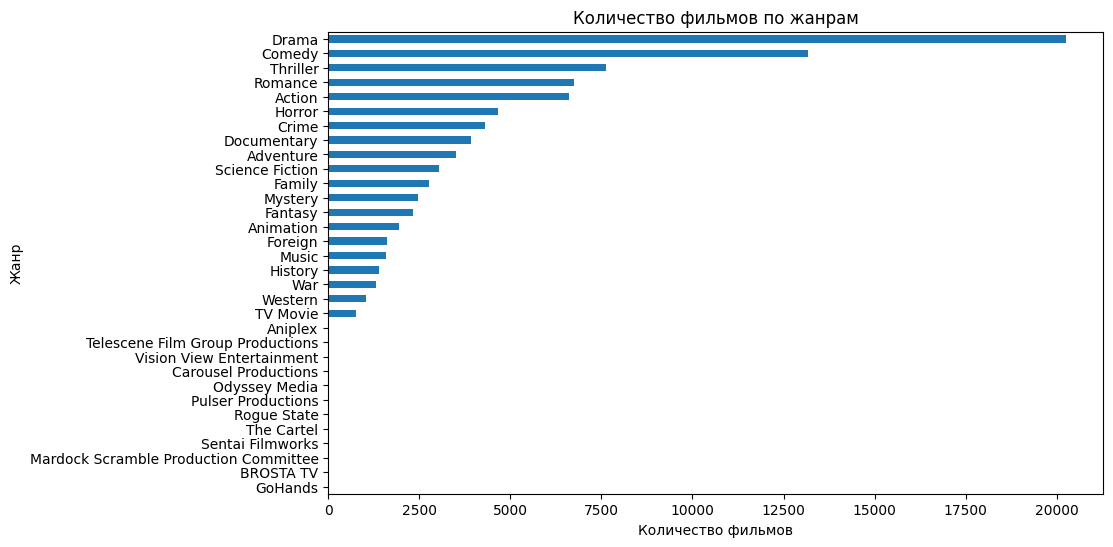

In [25]:
genre_counts = movies["genres_list"].explode().value_counts()

plt.figure(figsize=(10, 6))
genre_counts.sort_values().plot(kind="barh")

plt.title("Количество фильмов по жанрам")
plt.xlabel("Количество фильмов")
plt.ylabel("Жанр")
plt.show()

Посчитаем количество жанров у фильмов в среднем

In [26]:
movies["genres_count"] = movies["genres_list"].apply(len)

movies["genres_count"].describe()

,genres_count
count,45466.000000
mean,2.003827
std,1.131100
min,0.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,8.000000


В среднем фильм относится примерно к двум жанрам, а у большинства фильмов указано от одного до трёх жанров. При этом минимальное значение равно 0, что подтверждает наличие фильмов с пустым списком жанров. Такие фильмы не будут информативны для жанрового baseline и будут исключены на этапе подготовки данных.

Посчитаем количество слов в каждом `overview`, чтобы оценить длину описаний и выявить пустые или слишком короткие тексты.


In [27]:
movies["overview_word_count"] = movies["overview"].fillna("").apply(lambda x: len(x.split()))

In [28]:
movies["overview_word_count"].describe()

,overview_word_count
count,45466.000000
mean,53.953020
std,35.415645
min,0.000000
25%,26.000000
50%,47.000000
75%,72.000000
max,187.000000


В среднем в описании 54 слова. Большинство имеют достаточную длину для применения текстовых методов. Минимальное значение равно 0 из-за пустых значений, их мы позже обработаем.

Посмотрим на самые короткие описания, чтобы проверить, содержат ли они полезную информацию.

In [29]:
movies.loc[movies["overview_word_count"] <= 5, "overview"].value_counts().head(20)

,count
overview,
No overview found.,133
No Overview,7
,5
Released,3
No movie overview available.,3
Bollywood 2009,2
A film by Jem Cohen,2
No overview yet.,2
German Comedy,1


Среди коротких описаний встречаются служебные значения, такие как No overview found., No Overview, No movie overview available. и другие варианты отсутствующего описания. Такие значения не содержат информации о содержании фильма и должны быть исключены перед применением текстовых методов.

In [30]:
no_overview_values = [
    "No overview found.",
    "No Overview",
    "No movie overview available.",
    "No overview yet."
]

Сформируем булеву маску invalid_overview, которая отмечает все фильмы без пригодного текстового описания: пропуски NaN, пустые строки и найденные ранее служебные заглушки. Затем посчитаем количество таких записей.

In [31]:
invalid_overview = (
    movies["overview"].isna()
    | movies["overview"].fillna("").str.strip().eq("")
    | movies["overview"].isin(no_overview_values)
)

invalid_overview.sum()

np.int64(1104)

В датасете обнаружено 1104 фильмов без пригодного описания. Эти описания будут исключены на этапе подготовки данных.

## 4. Подготовка, очистка и объединение датасетов




Перед объединением датасетов удалим записи, которые не подходят для сравнения всех трёх методов: фильмы с некорректными значениями жанров, без указанных жанров и без пригодного текстового описания.

In [32]:
invalid_genre_mask = movies["genres_list"].apply(lambda genres: (len(genres) == 0 or any(genre not in valid_genres for genre in genres)))

invalid_overview_mask = (
    movies["overview"].isna()
    | movies["overview"].fillna("").str.strip().eq("")
    | movies["overview"].isin(no_overview_values)
)

movies_clean = movies[
    ~invalid_genre_mask
    & ~invalid_overview_mask
].copy()

movies_clean = movies_clean.reset_index(drop=True)

In [33]:
print("До очистки:", movies.shape)
print("После очистки:", movies_clean.shape)

До очистки: (45466, 27)
После очистки: (42194, 27)


Для сравнения методов нужен единый набор фильмов, который одновременно содержит жанры, описание и movie_id из MovieLens.

Сопоставлять фильмы будем по нормализованному названию и году выпуска.

Выделим год выпуска в обоих датасетах и отделим год от названия фильма в MovieLens.


In [34]:
movies_clean["year"] = pd.to_datetime(movies_clean["release_date"],errors="coerce").dt.year

В MovieLens год выпуска указан  в названии фильма. Извлечём его в отдельный столбец year, а из title удалим год и сохраним очищенное название в title_clean.

In [35]:
tag_movies["year"] = (tag_movies["title"].str.extract(r"\((\d{4})\)$")[0].astype("Int64"))

tag_movies["title_clean"] = (tag_movies["title"].str.replace(r"\s*\(\d{4}\)$", "", regex=True).str.strip())

Названия в MovieLens могут отличаться по форме записи: например, `American President, The` вместо `The American President`, а альтернативные названия часто указаны в скобках. Нормализуем эти варианты перед объединением.


In [36]:
def normalize_title(title):
    title = str(title).strip()

    for article in ["The", "A", "An"]:
        suffix = f", {article}"

        if title.endswith(suffix):
            title = article + " " + title[:-len(suffix)]

    return title

In [37]:
tag_movies["title_norm"] = tag_movies["title_clean"].apply(normalize_title)

movies_clean["title_norm"] = movies_clean["title"].apply(normalize_title)

Часть фильмов содержит в конце названия альтернативное или оригинальное название в скобках, из-за чего они не сопоставляются между датасетами. Создадим дополнительную нормализованную версию названия title_norm2, удалив последний блок в скобках и повторно применив normalize_title.

In [38]:
tag_movies["title_norm2"] = (
    tag_movies["title_norm"]
    .str.replace(r"\s*\([^()]*\)$", "", regex=True)
    .str.strip()
    .apply(normalize_title)
)

Объединим MovieLens с очищенным The Movies Dataset по нормализованному названию и году выпуска. Используем title_norm2, в котором дополнительно удалены альтернативные названия в скобках.


In [39]:
movies_merged = tag_movies.merge(
    movies_clean,
    left_on=["title_norm2", "year"],
    right_on=["title_norm", "year"],
    how="left",
    suffixes=("_tag", "_movies")
)

Проверим результат объединения: количество успешно сопоставленных и несопоставленных фильмов, а также наличие дубликатов movie_id.

In [40]:
movies_merged["id"].notna().sum()

np.int64(8615)

In [41]:
movies_merged["id"].isna().sum()

np.int64(1138)

In [42]:
movies_merged["movie_id"].duplicated().sum()

np.int64(19)

Удалось сопоставить 8615 фильмов. Для 1138 фильмов соответствие не найдено. Также обнаружено 19 повторных строк по movie_id; далее проверим, скольким уникальным movie_id они соответствуют. Перед дальнейшим анализом необходимо проверить причины появления дубликатов и оставить для каждого фильма одну однозначную запись.

In [43]:
duplicates = movies_merged[
    movies_merged["movie_id"].duplicated(keep=False)
]

duplicates[
    ["movie_id", "title_tag", "title_movies", "year", "id"]
].sort_values("movie_id")

,movie_id,title_tag,title_movies,year,id
631,690,"Promise, The (Versprechen, Das) (1995)",The Promise,1995,105045
632,690,"Promise, The (Versprechen, Das) (1995)",The Promise,1995,105045
749,838,Emma (1996),Emma,1996,3573
750,838,Emma (1996),Emma,1996,12254
878,976,"Farewell to Arms, A (1932)",A Farewell to Arms,1932,22649
879,976,"Farewell to Arms, A (1932)",A Farewell to Arms,1932,22649
2037,2322,Soldier (1998),Soldier,1998,9425
2038,2322,Soldier (1998),Soldier,1998,54959
2312,2618,"Castle, The (1997)",The Castle,1997,13852
2313,2618,"Castle, The (1997)",The Castle,1997,26891


После объединения обнаружены повторяющиеся movie_id. В некоторых случаях это полные дубликаты, а в других одному фильму MovieLens соответствуют несколько записей The Movies Dataset с одинаковым названием и годом. Удалим такие записи.

In [44]:
duplicate_movie_ids = movies_merged.loc[movies_merged["movie_id"].duplicated(keep=False),"movie_id"].unique()

len(duplicate_movie_ids)

19

In [45]:
movies_matched = movies_merged[
    movies_merged["id"].notna()
    & ~movies_merged["movie_id"].isin(duplicate_movie_ids)
].copy()

movies_matched = movies_matched.reset_index(drop=True)

In [46]:
movies_matched["movie_id"].is_unique

True

In [47]:
movies_matched.shape

(8577, 35)

Сформируем итоговый датасет movies_final из однозначно сопоставленных фильмов и сбросим индекс, чтобы строки DataFrame соответствовали строкам матриц признаков.

In [48]:
movies_final = movies_matched.copy()

movies_final = movies_final.reset_index(drop=True)

In [49]:
movies_final.shape

(8577, 35)

In [50]:
movies_final["overview_word_count"].min()

6.0

In [51]:
movies_final["movie_id"].is_unique

True

Итоговая выборка содержит только однозначно сопоставленные фильмы с жанрами и пригодными текстовыми описаниями. movie_id уникален, а минимальная длина overview составляет 6 слов. Теперь данные готовы для построения трёх методов поиска похожих фильмов.

## 5. Baseline по жанрам

В качестве простого baseline представим каждый фильм бинарным вектором жанров с помощью `MultiLabelBinarizer`.

Сходство между фильмами будем вычислять по косинусной мере.


In [52]:
mlb = MultiLabelBinarizer()

genres_matrix = mlb.fit_transform(movies_final["genres_list"])

In [53]:
genres_matrix.shape

(8577, 20)

В результате получена матрица размером 8577 × 20: 8577 фильмов и 20 уникальных жанров.

In [54]:
mlb.classes_

array(['Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
       'Documentary', 'Drama', 'Family', 'Fantasy', 'Foreign', 'History',
       'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction',
       'TV Movie', 'Thriller', 'War', 'Western'], dtype=object)

Для поиска похожих фильмов будем использовать косинусное сходство. Для бинарных жанровых векторов высокая косинусная близость означает большое совпадение наборов жанров.

На примере `The Matrix` проверим, как выглядит жанровый вектор фильма.


In [55]:
matrix_movie = movies_final[movies_final["title_movies"] == "The Matrix"]

matrix_movie[["title_movies", "year", "genres_list"]]

,title_movies,year,genres_list
1996,The Matrix,1999,"[Action, Science Fiction]"


In [56]:
matrix_movie_idx = movies_final[movies_final["title_movies"] == "The Matrix"].index[0]

matrix_movie_idx

np.int64(1996)

Для The Matrix указаны два жанра - Action и Science Fiction. Посмотрим, как они представлены в бинарном векторе.

In [57]:
pd.DataFrame([genres_matrix[matrix_movie_idx]], columns=mlb.classes_)

,Action,Adventure,Animation,Comedy,Crime,Documentary,Drama,Family,Fantasy,Foreign,History,Horror,Music,Mystery,Romance,Science Fiction,TV Movie,Thriller,War,Western
0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0


Оформим поиск похожих фильмов в функцию и проверим рекомендации на двух примерах.


Создадим функцию recommend_by_genres, которая для выбранного фильма:

1. получает его жанровый вектор;
2. вычисляет cosine similarity со всеми фильмами;
3. сортирует фильмы по убыванию сходства;
4. исключает сам исходный фильм;
5. возвращает Top-K наиболее похожих фильмов.

In [58]:
def recommend_by_genres(movie_title, top_k=10):
    # Находим индекс фильма
    movie_idx = movies_final[movies_final["title_movies"] == movie_title].index[0]

    # Берём его жанровый вектор
    movie_vector = genres_matrix[movie_idx].reshape(1, -1)

    # Считаем сходство со всеми фильмами
    similarities = cosine_similarity(movie_vector, genres_matrix)[0]

    # Сортируем индексы по убыванию сходства
    similar_indices = similarities.argsort()[::-1]

    # Исключаем сам фильм
    similar_indices = similar_indices[similar_indices != movie_idx]

    # Берём top-k
    top_indices = similar_indices[:top_k]

    # Формируем таблицу результатов
    result = movies_final.iloc[top_indices][["title_movies", "year", "genres_list"]].copy()

    result["similarity"] = similarities[top_indices]

    return result

In [59]:
recommend_by_genres("The Matrix", top_k=10)

,title_movies,year,genres_list,similarity
4918,Eve of Destruction,1991,"[Action, Science Fiction]",1.0
59,Lawnmower Man 2: Beyond Cyberspace,1996,"[Action, Science Fiction]",1.0
5830,"I, Robot",2004,"[Action, Science Fiction]",1.0
873,Escape from New York,1981,"[Science Fiction, Action]",1.0
2180,Universal Soldier: The Return,1999,"[Action, Science Fiction]",1.0
3851,The Final Countdown,1980,"[Action, Science Fiction]",1.0
3565,Cyborg,1989,"[Action, Science Fiction]",1.0
1964,Battle for the Planet of the Apes,1973,"[Action, Science Fiction]",1.0
1965,Conquest of the Planet of the Apes,1972,"[Action, Science Fiction]",1.0
1966,Escape from the Planet of the Apes,1971,"[Action, Science Fiction]",1.0


In [60]:
recommend_by_genres("Toy Story", top_k=10)

,title_movies,year,genres_list,similarity
6273,The Lion King 1½,2004,"[Animation, Comedy, Family]",1.0
6241,An Extremely Goofy Movie,2000,"[Animation, Family, Comedy]",1.0
8521,Despicable Me 2,2013,"[Animation, Comedy, Family]",1.0
6647,Chicken Little,2005,"[Animation, Family, Comedy]",1.0
5987,The SpongeBob SquarePants Movie,2004,"[Animation, Comedy, Family]",1.0
7059,How the Grinch Stole Christmas!,1966,"[Animation, Family, Comedy]",1.0
7101,Surf's Up,2007,"[Animation, Comedy, Family]",1.0
7056,Meet the Robinsons,2007,"[Animation, Comedy, Family]",1.0
6712,Hoodwinked!,2005,"[Animation, Comedy, Family]",1.0
5143,Looney Tunes: Back in Action,2003,"[Animation, Comedy, Family]",1.0


Поиск похожих фильмов по жанрам корректно находит фильмы с совпадающими наборами жанров. Однако многие фильмы получают одинаковое значение similarity = 1, если их жанровые векторы полностью совпадают. Поэтому такой подход хорошо подходит как простой baseline, но слабо различает фильмы внутри одного и того же жанрового набора.

## 6. TF-IDF по описаниям

Второй метод использует текстовые описания `overview`. С помощью `TF-IDF` преобразуем каждое описание в вектор, где больший вес получают слова, характерные для конкретных документов, а часто встречающиеся слова имеют меньший вес. Английские стоп-слова исключим с помощью stop_words="english".
После этого фильмы снова сравниваются с помощью cosine similarity.


In [61]:
tfidf = TfidfVectorizer(stop_words="english")

tfidf_matrix = tfidf.fit_transform(movies_final["overview"])

tfidf_matrix.shape


(8577, 28882)

Получена TF-IDF-матрица размером 8577 × 28882: строки соответствуют фильмам, а столбцы - словам (термам), выделенным из описаний фильмов.

Создадим функцию recommend_by_tfidf, которая для выбранного фильма вычисляет cosine similarity его TF-IDF-вектора с векторами всех остальных фильмов и возвращает Top-K наиболее похожих по текстовым описаниям.

In [62]:
def recommend_by_tfidf(movie_title, top_k=10):
    # Находим индекс фильма
    movie_idx = movies_final[movies_final["title_movies"] == movie_title].index[0]

    # Считаем сходство по TF-IDF
    similarities = cosine_similarity(tfidf_matrix[movie_idx], tfidf_matrix)[0]

    # Сортируем индексы по убыванию сходства
    similar_indices = similarities.argsort()[::-1]

    # Исключаем сам фильм
    similar_indices = similar_indices[similar_indices != movie_idx]

    # Берём top-k
    top_indices = similar_indices[:top_k]

    # Формируем таблицу
    result = movies_final.iloc[top_indices][["title_movies", "year", "genres_list", "overview"]].copy()

    result["similarity"] = similarities[top_indices]

    return result

Посмотрим результаты для `The Matrix` и `Toy Story`.


In [63]:
recommend_by_tfidf("The Matrix", top_k=10)

,title_movies,year,genres_list,overview,similarity
138,Hackers,1995,"[Action, Crime, Thriller, Drama]","Along with his new friends, a teenager who was...",0.189179
4975,Commando,1985,"[Action, Adventure, Thriller]","John Matrix, the former leader of a special co...",0.167087
6743,Pulse,2006,"[Horror, Thriller]",When their computer hacker friend accidentally...,0.162928
6276,The Animatrix,2003,"[Animation, Science Fiction]",Straight from the creators of the groundbreaki...,0.153242
7809,Avatar,2009,"[Action, Adventure, Fantasy, Science Fiction]","In the 22nd century, a paraplegic Marine is di...",0.132539
7831,Blood and Bone,2009,"[Drama, Action, Thriller]","In Los Angeles, an ex-con (White) takes the un...",0.131147
501,Hellraiser: Bloodline,1996,"[Horror, Thriller, Science Fiction]","In the 22nd century, a scientist attempts to r...",0.119514
7117,Live Free or Die Hard,2007,"[Action, Thriller]","John McClane is back and badder than ever, and...",0.117414
6104,Colossus: The Forbin Project,1970,"[Science Fiction, Thriller]",Forbin is the designer of an incredibly sophis...,0.116344
59,Lawnmower Man 2: Beyond Cyberspace,1996,"[Action, Science Fiction]",Jobe is resuscitated by Jonathan Walker. He wa...,0.115577


In [64]:
recommend_by_tfidf("Toy Story", top_k=10)

,title_movies,year,genres_list,overview,similarity
7935,Toy Story 3,2010,"[Animation, Family, Comedy]","Woody, Buzz, and the rest of Andy's toys haven...",0.518927
2427,Toy Story 2,1999,"[Animation, Comedy, Family]","Andy heads off to Cowboy Camp, leaving his toy...",0.448203
858,Rebel Without a Cause,1955,[Drama],"After moving to a new town, troublemaking teen...",0.172535
2473,Man on the Moon,1999,"[Comedy, Drama, Romance]",A film about the life and career of the eccent...,0.148297
6941,For Your Consideration,2006,"[Comedy, Drama]",Three actors learn that their respective perfo...,0.145100
405,Malice,1993,"[Drama, Crime]",A tale about a happily married couple who woul...,0.143447
4523,Class of 1984,1982,"[Action, Drama, Horror, Crime, Thriller]",Andy is a new teacher at a inner city high sch...,0.141741
7021,Factory Girl,2006,[Drama],"In the mid-1960s, wealthy debutant Edie Sedgwi...",0.139659
1555,Condorman,1981,"[Comedy, Action, Adventure]",Comic artist and writer Woody performs a simpl...,0.132897
5661,The First $20 Million Is Always the Hardest,2002,[Comedy],"Andy, a successful marketing guy quits his job...",0.129461


В отличие от поиска по жанрам(baseline), TF-IDF позволяет различать фильмы даже при одинаковых жанрах, поскольку учитывает содержание их описаний. Для Toy Story среди наиболее похожих фильмов появляются продолжения Toy Story 2 и Toy Story 3. Однако TF-IDF опирается на совпадение слов и не учитывает их смысловой контекст, поэтому среди рекомендаций могут встречаться фильмы, связанные лишь отдельными словами из описания.

## 7. Sentence Transformer

Третий метод использует предобученную модель `all-MiniLM-L6-v2`. Она преобразует всё описание фильма в плотный семантический вектор размерности 384.

Модель не дообучается на нашем датасете — используется готовое представление текста.


Загрузим предобученную модель `all-MiniLM-L6-v2`, которая будет использоваться для получения семантических представлений описаний фильмов.

In [ ]:
model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 90.9MB            

model.safetensors: downloading bytes:           |  0.00B            

Преобразуем описания всех фильмов в семантические эмбеддинги с помощью выбранной модели. Для каждого overview модель создаёт вектор размерности 384, отражающий смысловое содержание текста.

In [ ]:
embeddings = model.encode(movies_final["overview"].tolist(), show_progress_bar=True)

Batches:   0%|          | 0/269 [00:00<?, ?it/s]

In [ ]:
embeddings.shape

(8577, 384)

Получена матрица размером 8577 × 384: каждому фильму соответствует один 384-мерный семантический вектор.

Создадим функцию recommend_by_semantics, которая для выбранного фильма вычисляет cosine similarity его семантического эмбеддинга с эмбеддингами всех остальных фильмов и возвращает Top-K наиболее похожих по смыслу описания.

In [ ]:
def recommend_by_semantics(movie_title, top_k=10):
    # Находим индекс фильма
    movie_idx = movies_final[movies_final["title_movies"] == movie_title].index[0]

    # Считаем косинусное сходство между эмбеддингом фильма
    # и эмбеддингами всех остальных фильмов
    similarities = cosine_similarity(embeddings[movie_idx].reshape(1, -1), embeddings)[0]

    # Сортируем по убыванию сходства
    similar_indices = similarities.argsort()[::-1]

    # Исключаем сам фильм
    similar_indices = similar_indices[similar_indices != movie_idx]

    # Берём top-k
    top_indices = similar_indices[:top_k]

    # Формируем таблицу
    result = movies_final.iloc[top_indices][["title_movies", "year", "genres_list", "overview"]].copy()

    result["similarity"] = similarities[top_indices]

    return result

In [ ]:
recommend_by_semantics("The Matrix", top_k=10)

,title_movies,year,genres_list,overview,similarity
4975,Commando,1985,"[Action, Adventure, Thriller]","John Matrix, the former leader of a special co...",0.556395
4793,The Matrix Reloaded,2003,"[Adventure, Action, Thriller, Science Fiction]",Six months after the events depicted in The Ma...,0.545352
1079,Sneakers,1992,"[Comedy, Crime, Drama]",When shadowy U.S. intelligence agents blackmai...,0.540891
4986,Revolution OS,2001,[Documentary],REVOLUTION OS tells the inside story of the ha...,0.506364
3153,Antitrust,2001,"[Action, Crime, Drama]",A computer programmer's dream job at a hot Por...,0.502281
138,Hackers,1995,"[Action, Crime, Thriller, Drama]","Along with his new friends, a teenager who was...",0.493929
1912,Jumpin' Jack Flash,1986,"[Romance, Comedy, Thriller]","Terry works for a bank, and uses computers to ...",0.486739
4131,Enigma,2001,"[Mystery, Drama, Thriller, Romance, War]",A romantic thriller based around the World War...,0.484001
6276,The Animatrix,2003,"[Animation, Science Fiction]",Straight from the creators of the groundbreaki...,0.477767
2264,Total Recall,1990,"[Action, Adventure, Science Fiction]",Construction worker Douglas Quaid discovers a ...,0.476002


In [ ]:
recommend_by_semantics("Toy Story", top_k=10)

,title_movies,year,genres_list,overview,similarity
7935,Toy Story 3,2010,"[Animation, Family, Comedy]","Woody, Buzz, and the rest of Andy's toys haven...",0.758612
2427,Toy Story 2,1999,"[Animation, Comedy, Family]","Andy heads off to Cowboy Camp, leaving his toy...",0.740059
1510,Child's Play 3,1991,"[Thriller, Horror, Action]",It's been eight years since the events in the ...,0.464866
2865,Firestarter,1984,"[Fantasy, Drama, Horror, Action, Thriller]","As youths, Andy McGee (David Keith) and his fu...",0.423896
2132,Radio Days,1987,"[Comedy, Drama]",The Narrator (Woody Allen) tells us how the ra...,0.414764
8513,The Kings of Summer,2013,"[Comedy, Drama]","Joe Toy, on the verge of adolescence, finds hi...",0.406576
491,Pinocchio,1940,"[Animation, Family]",Lonely toymaker Geppetto has his wishes answer...,0.401973
1521,Gremlins 2: The New Batch,1990,"[Comedy, Horror, Fantasy]",Young sweethearts Billy and Kate move to the B...,0.385681
1560,Flight of the Navigator,1986,"[Family, Science Fiction, Adventure]",This 1986 Disney adventure tells the story of ...,0.364465
2294,Home Alone 2: Lost in New York,1992,"[Comedy, Family, Adventure, Crime]","Instead of flying to Florida with his folks, K...",0.364445


Sentence Transformer учитывает не только совпадение отдельных слов, но и семантическое содержание описаний. Это позволяет находить фильмы с похожим смыслом даже при различающейся лексике. Однако визуальной оценки отдельных рекомендаций недостаточно для объективного сравнения методов, поэтому далее оценим все три подхода с помощью MovieLens Tag Genome.

## 8. Оценка через MovieLens Tag Genome

Tag Genome содержит для каждого фильма вектор из 1128 значений `relevance` — насколько сильно фильм соответствует каждому пользовательскому тегу.

Для пары фильмов будем вычислять cosine similarity между их Tag Genome-векторами.

Основная proxy-метрика проекта - **Mean Tag Similarity@10**: среднее Tag Genome-сходство исходного фильма с десятью фильмами, рекомендованными методом.

Tag Genome не используется при поиске рекомендаций и служит только независимым источником оценки.


В исходном `tag_relevance` каждому сочетанию фильма и тега соответствует отдельная строка. Посмотрим на первые несколько записей.

In [ ]:
tag_relevance.head(10)

,movie_id,tag_id,relevance
0,1,0,0.032
1,1,1,0.035
2,1,2,0.070
3,1,3,0.114
4,1,4,0.105
5,1,5,0.186
6,1,6,0.040
7,1,7,0.208
8,1,8,0.261
9,1,9,0.032


Для дальнейшего сравнения фильмов удобнее представить данные в виде матрицы, где одна строка соответствует одному фильму, каждый столбец — отдельному тегу, а в ячейках находятся значения relevance. Выполним такое преобразование с помощью pivot.

In [ ]:
tag_matrix = tag_relevance.pivot(index="movie_id", columns="tag_id", values="relevance")

tag_matrix.iloc[:5, :10]

tag_id,0,1,2,3,4,5,6,7,8,9
movie_id,,,,,,,,,,
1,0.032,0.035,0.070,0.114,0.105,0.186,0.040,0.208,0.261,0.032
2,0.041,0.051,0.056,0.053,0.111,0.128,0.065,0.127,0.117,0.026
3,0.037,0.051,0.028,0.067,0.043,0.073,0.058,0.257,0.065,0.031
4,0.030,0.031,0.033,0.030,0.063,0.036,0.025,0.109,0.056,0.030
5,0.042,0.053,0.039,0.031,0.065,0.107,0.028,0.123,0.042,0.025


In [ ]:
tag_matrix.shape

(9734, 1128)

Получена матрица размером 9734 × 1128: 9734 фильма представлены векторами из 1128 значений relevance.

Теперь оставим в Tag Genome только фильмы из movies_final и расположим их в том же порядке. Это необходимо, чтобы строки Tag Genome соответствовали тем же фильмам, что и строки матриц признаков наших трёх методов.

Сначала получим последовательность movie_id из movies_final, затем выберем из tag_matrix только эти фильмы в том же порядке.

In [ ]:
final_movie_ids = movies_final["movie_id"]

In [ ]:
tag_matrix_final = tag_matrix.loc[final_movie_ids]

In [ ]:
tag_matrix_final.shape

(8577, 1128)

Проверим, что порядок фильмов в tag_matrix_final полностью совпадает с порядком строк в movies_final.

In [ ]:
(tag_matrix_final.index.to_numpy() == movies_final["movie_id"].to_numpy()).all()

np.True_

Порядок фильмов совпадает. Значит, строка с индексом i в tag_matrix_final соответствует тому же фильму, что и строка i в жанровой, TF-IDF и semantic-матрицах

Для наглядности рассмотрим Tag Genome на примере The Matrix. Найдём фильм в итоговом датасете и получим его movie_id из MovieLens.


In [ ]:
matrix_idx = movies_final[movies_final["title_movies"] == "The Matrix"].index[0]

matrix_movie_id = movies_final.loc[matrix_idx, "movie_id"]

matrix_movie_id

np.int64(2571)

Посмотрим, какие теги имеют наибольшие значения relevance для The Matrix. Это позволит наглядно увидеть, как Tag Genome описывает содержание фильма.

In [ ]:
matrix_tags = tag_matrix_final.loc[matrix_movie_id]

top_tag_ids = matrix_tags.sort_values(ascending=False).head(10)

top_tag_ids

,2571
tag_id,
279,0.997
336,0.993
889,0.992
950,0.989
885,0.989
888,0.987
1011,0.987
1089,0.987
1091,0.986


Пока отображаются только tag_id. Чтобы интерпретировать результат, сопоставим эти идентификаторы с названиями тегов из таблицы tags.

In [ ]:
top_tags = (top_tag_ids
    .rename("relevance")
    .reset_index()
    .merge(tags[["tag_id", "tag"]], on="tag_id")
    .sort_values("relevance", ascending=False)
)

top_tags

,tag_id,relevance,tag
0,279,0.997,cyberpunk
1,336,0.993,dystopic future
2,889,0.992,scifi
3,950,0.989,special effects
4,885,0.989,sci fi
5,888,0.987,science fiction
6,1011,0.987,technology
7,1089,0.987,visual
8,1091,0.986,visually stunning
9,1086,0.985,virtual reality


Наиболее релевантные теги хорошо отражают содержание и особенности The Matrix: среди них cyberpunk, dystopic future, science fiction, technology и virtual reality. Также Tag Genome учитывает визуальные характеристики фильма через теги special effects, visual и visually stunning. Это показывает, что Tag Genome содержит более детальное описание фильма, чем только его жанры.

Для примера вычислим Tag Genome-сходство между The Matrix и The Matrix Reloaded. Найдём movie_id второго фильма, получим 1128-мерные Tag Genome-векторы обоих фильмов и рассчитаем между ними cosine similarity.

In [ ]:
reloaded_idx = movies_final[movies_final["title_movies"] == "The Matrix Reloaded"].index[0]

reloaded_movie_id = movies_final.loc[reloaded_idx, "movie_id"]

matrix_tag_vector = tag_matrix_final.loc[matrix_movie_id].values.reshape(1, -1)
reloaded_tag_vector = tag_matrix_final.loc[reloaded_movie_id].values.reshape(1, -1)

tag_similarity = cosine_similarity(matrix_tag_vector, reloaded_tag_vector)[0][0]

tag_similarity

np.float64(0.8890842087426867)

Tag Genome-сходство между The Matrix и The Matrix Reloaded составляет около 0,89, что указывает на высокую близость их теговых профилей. Аналогичным способом далее будем оценивать фильмы, рекомендованные каждым из трёх методов.

Перейдём от оценки отдельных пар к массовой оценке рекомендаций.

Преобразуем итоговую Tag Genome-матрицу в NumPy-массив для дальнейших вычислений и создадим массив индексов всех фильмов из movies_final.

In [ ]:
tag_vectors = tag_matrix_final.to_numpy()

In [ ]:
tag_vectors.shape

(8577, 1128)

In [ ]:
all_indices = np.arange(len(movies_final))

Создадим функцию массовой оценки. Для каждого фильма она находит Top-K наиболее похожих фильмов по признакам оцениваемого метода, а затем вычисляет среднее Tag Genome-сходство исходного фильма с полученными рекомендациями. В результате функция возвращает значение Tag Similarity@K для каждого фильма.

In [ ]:
def evaluate_model_scores(feature_matrix, tag_vectors, indices, top_k=10):
    scores = []

    for i in indices:
        # Сходство текущего фильма со всеми фильмами
        similarities = cosine_similarity(feature_matrix[i:i+1], feature_matrix)[0]

        # Исключаем сам фильм
        similarities[i] = -1

        # Берём top-k наиболее похожих
        top_indices = similarities.argsort()[::-1][:top_k]

        # Считаем сходство рекомендаций с исходным фильмом по Tag Genome
        tag_similarities = cosine_similarity(tag_vectors[i:i+1], tag_vectors[top_indices])[0]

        # Сохраняем среднее качество рекомендаций для этого фильма
        scores.append(tag_similarities.mean())

    return np.array(scores)


## 9. Сравнение методов

Оценим все три метода на одном и том же наборе из 8577 фильмов. Для каждого фильма получим значение Tag Similarity@10 отдельно для поиска похожих фильмов по жанру, TF-IDF и Sentence Transformer.

In [ ]:
genre_scores = evaluate_model_scores(genres_matrix, tag_vectors, all_indices, top_k=10)

tfidf_scores = evaluate_model_scores(tfidf_matrix, tag_vectors, all_indices, top_k=10)

semantic_scores = evaluate_model_scores(embeddings, tag_vectors, all_indices, top_k=10)

Для каждого метода получено 8577 значений Tag Similarity@10 - по одному для каждого фильма. Объединим полученные значения Tag Similarity@10 в одну таблицу. Каждая строка соответствует одному исходному фильму, а столбцы Genres, TF-IDF и Sentence Transformer показывают качество рекомендаций соответствующего метода.

In [ ]:
scores_df = pd.DataFrame({
    "title": movies_final["title_movies"],
    "Genres": genre_scores,
    "TF-IDF": tfidf_scores,
    "Sentence Transformer": semantic_scores
})

scores_df.head()

,title,Genres,TF-IDF,Sentence Transformer
0,Toy Story,0.759309,0.670287,0.728411
1,Jumanji,0.746001,0.647725,0.706842
2,Grumpier Old Men,0.716969,0.657123,0.735596
3,Waiting to Exhale,0.714693,0.731814,0.665006
4,Father of the Bride Part II,0.620613,0.640684,0.752036


Посчитаем описательную статистику и определим, какой метод дал максимальный `Tag Similarity@10` для каждого фильма.


In [ ]:
scores_df[["Genres", "TF-IDF", "Sentence Transformer"]].describe()

,Genres,TF-IDF,Sentence Transformer
count,8577.000000,8577.000000,8577.000000
mean,0.708540,0.666810,0.688380
std,0.050106,0.049595,0.052262
min,0.498924,0.482387,0.447439
25%,0.676861,0.634828,0.654020
50%,0.710918,0.667128,0.688086
75%,0.743546,0.697321,0.721714
max,0.878124,0.912209,0.923188


Наибольшее среднее значение Tag Similarity@10 показал рекомендация по жанрам baseline - 0.709.

Sentence Transformer занимает второе место со значением 0.688, а TF-IDF - третье со значением 0.667.
Медианные значения дают такой же порядок методов. При этом максимальные отдельные значения у текстовых методов выше, чем у рекомендаций по жанрам.

In [ ]:
scores_df["best_method"] = scores_df[["Genres", "TF-IDF", "Sentence Transformer"]].idxmax(axis=1)

In [ ]:
scores_df["best_method"].value_counts()

,count
best_method,
Genres,5187
Sentence Transformer,2483
TF-IDF,907


In [ ]:
scores_df["best_method"].value_counts(normalize=True) * 100

,proportion
best_method,
Genres,60.475691
Sentence Transformer,28.949516
TF-IDF,10.574793


Рекомендации по жанрам (baseline) показал лучший результат для 5187 фильмов (60,5%), Sentence Transformer — для 2483 фильмов (28,9%), а TF-IDF — для 907 фильмов (10,6%). Таким образом, преимущество жанрового метода наблюдается не только по среднему значению метрики, но и для большинства отдельных фильмов.

Визуализируем среднее качество методов и количество фильмов, для которых каждый метод оказался лучшим.


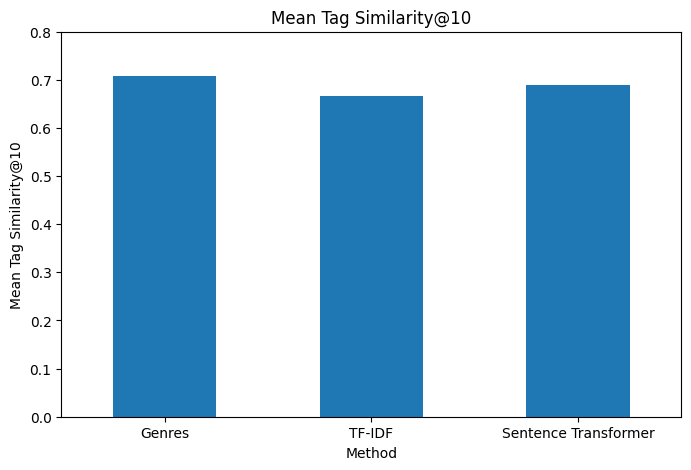

In [ ]:
mean_scores = scores_df[["Genres", "TF-IDF", "Sentence Transformer"]].mean()

mean_scores.plot(kind="bar", figsize=(8, 5))

plt.title("Mean Tag Similarity@10")
plt.ylabel("Mean Tag Similarity@10")
plt.xlabel("Method")
plt.xticks(rotation=0)
plt.ylim(0, 0.8)
plt.show()

Наибольшее среднее качество рекомендаций по метрике Mean Tag Similarity@10 показал рекомендации по жанрам baseline (0,709), далее следует Sentence Transformer (0,688), а наименьшее значение получил TF-IDF (0,667).

Дополнительно сравним, для какого количества фильмов каждый метод получил максимальный Tag Similarity@10.

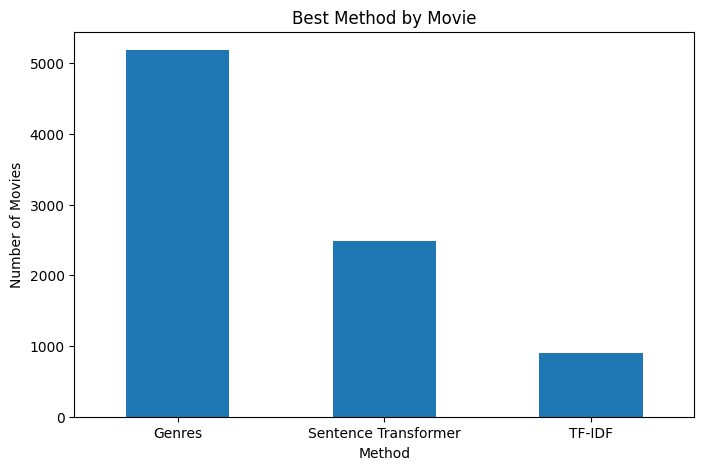

In [ ]:
win_counts = scores_df["best_method"].value_counts()

win_counts.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Best Method by Movie")
plt.ylabel("Number of Movies")
plt.xlabel("Method")
plt.xticks(rotation=0)
plt.show()

Рекомендации по жанрам baseline оказался лучшим для 5187 фильмов, Sentence Transformer — для 2483, а TF-IDF — для 907. Таким образом, жанровый подход лидирует не только по среднему значению метрики, но и показывает лучший результат для большинства фильмов итоговой выборки.

## 10. Выводы

В проекте были сравнены три подхода к поиску похожих фильмов:

- **Genres baseline** — `Mean Tag Similarity@10 = 0.7085`;
- **Sentence Transformer** — `0.6884`;
- **TF-IDF** — `0.6668`.

По выбранной proxy-метрике лучший средний результат показал простой метод рекомендации по жанру, использованный в качестве baseline. Он также оказался лучшим для **5187 фильмов (60.48%)**. Sentence Transformer победил для **2483 фильмов (28.95%)**, а TF-IDF — для **907 фильмов (10.57%)**.

Более сложный метод не обязательно превосходит простой baseline. В данном эксперименте жанры хорошо согласуются с профилями тегов MovieLens Tag Genome. При этом Sentence Transformer оказался лучшим почти для трети фильмов, поэтому семантическое представление описаний остаётся полезным для части объектов.



MovieLens Tag Genome используется как **proxy-метрика**. Поэтому результаты показывают, какой метод лучше согласуется именно с пользовательскими тегами Tag Genome.

Также метод рекомендаций по жанрам часто даёт одинаковое сходство нескольким фильмам с одним и тем же набором жанров, поэтому порядок внутри таких групп может быть условным.

### Демо-приложение

Для демонстрации лучшего по выбранной метрике метода подготовлено Streamlit-приложение, в котором пользователь выбирает фильм и получает список похожих фильмов по жанрам.


Ниже сохраняются данные для Streamlit и создаётся файл `app.py`.


In [ ]:
movies_app = movies_final[
    ["title_movies", "year", "genres_list"]
].copy()

movies_app.to_pickle("movies_app.pkl")

In [ ]:
%%writefile app.py

import streamlit as st
import pandas as pd

from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics.pairwise import cosine_similarity


# Загрузка данных
movies = pd.read_pickle("movies_app.pkl")
movies = movies.reset_index(drop=True)

# Название фильма + год для выпадающего списка
movies["display_title"] = (
    movies["title_movies"]
    + " ("
    + movies["year"].astype(int).astype(str)
    + ")"
)


# Создание матрицы жанров
mlb = MultiLabelBinarizer()
genres_matrix = mlb.fit_transform(movies["genres_list"])


# Функция рекомендаций
def recommend_by_genres(movie_idx, top_k=10):
    movie_vector = genres_matrix[movie_idx].reshape(1, -1)

    similarities = cosine_similarity(
        movie_vector,
        genres_matrix
    )[0]

    # Сортируем фильмы по сходству
    similar_indices = similarities.argsort()[::-1]

    # Исключаем выбранный фильм
    similar_indices = similar_indices[similar_indices != movie_idx]

    # Берём top-k
    top_indices = similar_indices[:top_k]

    result = movies.iloc[top_indices][
        ["title_movies", "year", "genres_list"]
    ].copy()

    result["similarity"] = similarities[top_indices]

    return result


# Интерфейс
st.title("Поиск похожих фильмов")

st.write(
    "Рекомендации строятся на основе сходства жанров фильмов."
)

selected_movie = st.selectbox(
    "Выберите фильм:",
    movies["display_title"].sort_values()
)

# Получаем индекс выбранного фильма
movie_idx = movies[
    movies["display_title"] == selected_movie
].index[0]

top_k = st.slider(
    "Количество рекомендаций:",
    min_value=5,
    max_value=20,
    value=10
)


if st.button("Найти похожие фильмы"):
    recommendations = recommend_by_genres(
        movie_idx,
        top_k
    )

    st.subheader("Рекомендации")

    for _, row in recommendations.iterrows():
        genres = ", ".join(row["genres_list"])

        st.write(
            f"**{row['title_movies']} ({int(row['year'])})**  \n"
            f"{genres}"
        )

Writing app.py


## 11. Проверка метода поиска по жанрам на новых фильмах

Проверим работу лучшего по выбранной метрике метода на новых данных. Сформируем небольшую выборку из 10 современных фильмов, которые не входят в основной датасет. Для каждого фильма зададим жанры из того же набора, который использовался при построении жанрового baseline.

Для преобразования новых данных используем уже обученный MultiLabelBinarizer.

In [ ]:
inference_movies = pd.DataFrame({
    "title": [
        "Dune: Part Two",
        "Furiosa: A Mad Max Saga",
        "The Substance",
        "Civil War",
        "Challengers",
        "Inside Out 2",
        "The Wild Robot",
        "Conclave",
        "Anora",
        "Nosferatu"
    ],
    "year": [
        2024, 2024, 2024, 2024, 2024,
        2024, 2024, 2024, 2024, 2024
    ],
    "genres_list": [
        ["Adventure", "Science Fiction"],
        ["Action", "Adventure", "Science Fiction"],
        ["Horror", "Science Fiction"],
        ["Action", "Drama"],
        ["Drama", "Romance"],
        ["Animation", "Family", "Comedy"],
        ["Animation", "Science Fiction", "Family"],
        ["Drama", "Thriller"],
        ["Drama", "Comedy", "Romance"],
        ["Horror", "Drama", "Fantasy"]
    ]
})

inference_movies

,title,year,genres_list
0,Dune: Part Two,2024,"[Adventure, Science Fiction]"
1,Furiosa: A Mad Max Saga,2024,"[Action, Adventure, Science Fiction]"
2,The Substance,2024,"[Horror, Science Fiction]"
3,Civil War,2024,"[Action, Drama]"
4,Challengers,2024,"[Drama, Romance]"
5,Inside Out 2,2024,"[Animation, Family, Comedy]"
6,The Wild Robot,2024,"[Animation, Science Fiction, Family]"
7,Conclave,2024,"[Drama, Thriller]"
8,Anora,2024,"[Drama, Comedy, Romance]"
9,Nosferatu,2024,"[Horror, Drama, Fantasy]"
